# Instructor model · Mirror project · Reliability over a short path

**Core scope:** final time 3, with supplied arithmetic and collision scaffolding. **Overall project budget:** about 12–18 hours including experiments, explanation, audit and revision. **Preparation:** Lectures 05–07, 12–13. See [the rubric](../projects/README.md) and [the source note](../Doc/mirror_trajectory_project.md).

Complete the event selector, run the certificate, and explain why every branch decision is valid. Derive the supplied collision/reflection formulas and audit the implementation in `vc/mirrors.py`. The model solution is instructor material; the original time-10 SIAM problem is an optional extension.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'solutions'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
from fractions import Fraction
from pathlib import Path
import json
import math
import platform
from importlib.metadata import version
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.mirrors import trace_lattice, final_distance, trajectory_record
from vc.mirror_exploration import approximate_path

def plot_path(path, centers):
    fig, ax = plt.subplots(figsize = (6, 6))
    for center in centers:
        ax.add_patch(Circle(center, 1 / 3, facecolor = "lightgray", edgecolor = "gray"))
    points = [(float(x), float(y)) for x, y in path["points"]]
    ax.plot([point[0] for point in points], [point[1] for point in points], "o-", color = "tab:red")
    ax.set(xlim = (-1.6, 1.6), ylim = (-0.6, 2.6), xlabel = "x", ylabel = "y", title = "Approximate short mirror trajectory")
    ax.set_aspect("equal")
    return fig

## Mathematical model and proof obligations

The ray starts at (1/2,1/10) with velocity (1,0). All integer lattice centers carry circular mirrors of radius r=1/3. Mirrors are disjoint because neighboring centers are at least one unit apart. The core final time is **T=3**, with final coordinate and distance widths at most **10⁻²⁰**. This is a shorter adaptation of SIAM Challenge Chapter 2, whose original final time is 10.

For a ray p+tv and a mirror center c, let n=p−c. The collision equation is

$$At^2+Bt+C=0,\qquad A=v\cdot v,\quad B=2n\cdot v,\quad C=n\cdot n-r^2.$$

For an outside start C>0, a moving-away ray B≥0 cannot hit the circle. A negative discriminant excludes intersection. A strictly positive discriminant and a positive smaller root supply a candidate entrance time. The implementation uses the rationalized root $2C/(-B+\sqrt{B^2-4AC})$ and checks all required inequalities. Tangency or uncertain geometry is inconclusive.

At an actual contact point, let n=contact−c, so n·n=r². Reflection is

$$v_{\rm new}=v-2\frac{v\cdot n}{r^2}n.$$

Expanding its squared norm proves speed preservation. A verified positive v_new·n means the ray departs outward and cannot hit this same convex circle again during that straight segment. This justifies skipping the immediately previous mirror; we never introduce a small arbitrary time offset to escape it.

Unit speed gives path length T and coordinate displacement at most T. A mirror center that can be hit lies within T+r of the initial position in each coordinate. Enumerating every lattice center in that rectangle is therefore enough even though the physical lattice is infinite. This bound also applies to a family of initial heights by using its full coordinate interval.

For each flight, certify the earliest collision against **all** other candidate times, then compare it with the remaining time. Propagate enclosures through reflection. A final-time position is returned only after the remaining segment is proved collision-free. The actual correlated trajectory remains inside these enclosures even though arithmetic boxes also contain impossible combinations of position and direction.

All computations assume ideal specular reflection, exact circular mirrors and lattice centers, and this deterministic ray model. A plot and agreement at two precisions supply exploratory evidence; the inequalities and complete candidate set supply the certificate. The supplied code is a conservative teaching implementation, not a general billiards solver.

## Task A · Separate precision from changed initial data

Compare nearest-rounded MPFR trajectories at 24, 53 and 100 bits, always starting from the same exact rational input. Then perturb the initial height at fixed precision. These are approximations, even when many digits agree.

In [3]:
for precision in [24, 53, 100]:
    approximate = approximate_path("3", precision = precision)
    print(precision, tuple(float(value) for value in approximate["endpoint"]), approximate["sequence"])
base = approximate_path("3", 100, "1/10")
perturbed = approximate_path("3", 100, Fraction(1, 10) + Fraction(1, 10 ** 8))
dx = float(perturbed["endpoint"][0]) - float(base["endpoint"][0])
dy = float(perturbed["endpoint"][1]) - float(base["endpoint"][1])
print("Approximate endpoint displacement:", math.hypot(dx, dy))

24 (-0.1435936689376831, 1.36784029006958) [(1, 0), (-1, 1), (0, 2)]
53 (-0.1435943030529661, 1.3678421779537846) [(1, 0), (-1, 1), (0, 2)]
100 (-0.1435943030529629, 1.3678421779537882) [(1, 0), (-1, 1), (0, 2)]
Approximate endpoint displacement: 3.2056686792547956e-06


**Worked explanation:** The precision comparison keeps the mathematical input fixed and changes arithmetic error. The perturbed-height comparison changes the trajectory itself. Neither approximate comparison proves an enclosure or a collision sequence. Writing α=(v·n)/r² gives ‖v−2αn‖²=‖v‖²−4α(v·n)+4α²r²=‖v‖² at an actual contact, because n·n=r². Initial speed one is therefore preserved.

## Task B · Certify the earliest event

Complete `student_select(checks, remaining)`, returning `(status, selected_hit_or_None)`. A check has `center`, `status`, and a time interval when its status is `hit`. First reject any inconclusive geometry. Finish only if there are no hits or every candidate lies strictly after the remaining-time interval. Otherwise select the smallest lower time bound, require its upper bound to be strictly below every competitor's lower bound, then require it to be strictly before the remaining time. Use statuses `inconclusive_geometry`, `finish`, `inconclusive_order`, `inconclusive_horizon`, or `collision`.

The driver trusts this callback's decisions. The path certificate therefore depends on your completed selector satisfying this contract; a `complete` status alone cannot verify an arbitrary callback. Task D checks the recorded inequalities directly.

In [4]:
def student_select(checks, remaining):
    if any(check.status.startswith("inconclusive") for check in checks):
        return "inconclusive_geometry", None
    hits = [check for check in checks if check.status == "hit"]
    if not hits or all(check.time.lo > remaining.hi for check in hits):
        return "finish", None
    first = min(hits, key = lambda check: check.time.lo)
    for other in hits:
        if other is not first and first.time.hi >= other.time.lo:
            return "inconclusive_order", None
    if first.time.hi >= remaining.lo:
        return "inconclusive_horizon", None
    return "collision", first

In [5]:
from vc.mirrors import HitCheck
ambiguous = [HitCheck((0, 0), "hit", Interval(1, 2)), HitCheck((1, 0), "hit", Interval("3/2", "5/2"))]
assert student_select(ambiguous, Interval(4))[0] == "inconclusive_order"
one = [HitCheck((0, 0), "hit", Interval(1, 2))]
assert student_select(one, Interval("1/2"))[0] == "finish"
assert student_select(one, Interval("3/2"))[0] == "inconclusive_horizon"
assert student_select(one, Interval(3))[0] == "collision"
assert student_select([], Interval(3))[0] == "finish"
uncertain = [HitCheck((0, 0), "inconclusive_tangent")]
assert student_select(uncertain, Interval(3))[0] == "inconclusive_geometry"
touching = [HitCheck((0, 0), "hit", Interval(1, 2)), HitCheck((1, 0), "hit", Interval(2, 3))]
assert student_select(touching, Interval(4))[0] == "inconclusive_order"

**Worked explanation:** Midpoints can be ordered even when admissible event times overlap; strict separation of intervals certifies a uniform earliest event. Unit speed bounds coordinate displacement by T; any center reachable by contact lies within T+r of an allowed initial coordinate. All integer centers in that rectangle are examined. The previous mirror can be skipped only because the actual state is on its boundary and the new direction has certified positive outward normal component; convexity then prevents return along that straight segment.

## Task C · Produce the final-time enclosure

Run the supplied driver using your event-selector callback. Report exact coordinate and distance bounds, and distinguish their widths from rounded display values. This target is part of the project claim; the driver itself reports completion of the trajectory, not attainment of a requested width.

Status: complete reason: All collisions before the requested time were resolved
Mirror sequence: [(1, 0), (-1, 1), (0, 2)]
x exact endpoints: [-372792124322698577228891931191297/2596148429267413814265248164610048, -372792124322698577228891077691391/2596148429267413814265248164610048]
Endpoint display ≈ -0.1435943030529629 -0.1435943030529629 width ≈ 3.287562052994182e-25
y exact endpoints: [887780330445111371919347536694839/649037107316853453566312041152512, 887780330445111371919347893809609/649037107316853453566312041152512]
Endpoint display ≈ 1.3678421779537882 1.3678421779537882 width ≈ 5.502224233007684e-25
Distance enclosure: [234005156529095395168298234432898132291/170141183460469231731687303715884105728, 234005156529095395168298333377328649917/170141183460469231731687303715884105728]


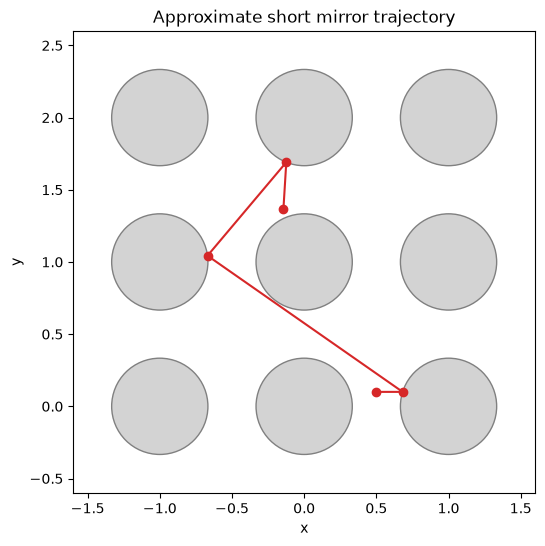

In [6]:
result = trace_lattice(final_time = "3", precision = 100, choose = student_select)
print("Status:", result.status, "reason:", result.reason)
assert result.status == "complete"
print("Mirror sequence:", [event.center for event in result.collisions])
for axis, bound in zip(["x", "y"], result.position):
    print(axis, "exact endpoints:", bound)
    print("Endpoint display ≈", float(bound.lo), float(bound.hi), "width ≈", float(bound.width()))
distance = final_distance(result)
print("Distance enclosure:", distance)
assert all(part.width() <= Fraction(1, 10 ** 20) for part in result.position)
assert distance.width() <= Fraction(1, 10 ** 20)
assert result.elapsed.lo == result.elapsed.hi == 3
path = approximate_path("3", precision = 53)
fig = plot_path(path, result.centers)
display(fig)
plt.close(fig)

**Worked explanation:** For the ideal lattice model with exact initial position (1/2,1/10), velocity (1,0), radius 1/3, and T=3, the 100-bit computation encloses the position and distance with each requested width below 10⁻²⁰. The certified sequence is (1,0), (−1,1), (0,2). The conclusion follows from enclosing arithmetic, complete candidate enumeration, strict event ordering, and reflection induction. Completion concerns reaching T; separate width checks establish the accuracy target. An interval width is an absolute error statement, not automatically a relative or correctly-rounded decimal-digit guarantee.

## Task D · Audit every decision

The following checks audit the saved inequalities. Explain why they are relevant and inspect the code that produced the bounds. This is not a separate proof of the arithmetic implementation.

In [7]:
previous_elapsed = Interval(0)
assert len(result.checks) == len(result.collisions) + 1
for event, checks in zip(result.collisions, result.checks):
    assert len(checks) == len(result.centers)
    assert {check.center for check in checks} == set(result.centers)
    assert not any(check.status.startswith("inconclusive") for check in checks)
    selected = next(check for check in checks if check.center == event.center)
    assert selected.status == "hit"
    assert selected.time.lo > 0 and selected.discriminant.lo > 0
    for other in checks:
        if other.status == "hit" and other.center != event.center:
            assert selected.time.hi < other.time.lo
    assert selected.time.hi < result.final_time - previous_elapsed.hi
    assert event.departure.lo > 0
    previous_elapsed = event.elapsed
final_checks = result.checks[-1]
remaining = Interval(result.final_time) - previous_elapsed
assert len(final_checks) == len(result.centers)
assert {check.center for check in final_checks} == set(result.centers)
for check in final_checks:
    assert not check.status.startswith("inconclusive")
    if check.status == "hit":
        assert check.time.lo > remaining.hi
print("Recorded event inequalities and final flight passed their audit.")

Recorded event inequalities and final flight passed their audit.


**Worked explanation:** Ideal specular reflection, exact geometry, speed preservation, the reachable-region proof, and the contact/departure argument connect the code to the physical model. The checks inspect recorded bounds but do not formally verify Arb or the Python implementation. Dropping a candidate without a geometric exclusion argument can select the wrong event and invalidate all later reflections, even if the reflection arithmetic itself encloses its inputs.

## Task E · Inconclusive and uncertain cases

Compare precision, input uncertainty, tangency, and a collision budget. In an incomplete run, position and elapsed time describe the last certified event state. They do not describe the requested final-time position.

In [8]:
for precision in [24, 53, 100, 160]:
    case = trace_lattice("3", precision, choose = student_select)
    width = max(part.width() for part in case.position) if case.status == "complete" else None
    print(precision, case.status, case.reason, "final width ≈", None if width is None else float(width))

uncertain_y = Interval("0.099999", "0.100001")
for precision in [100, 200]:
    family = trace_lattice("1/4", precision, uncertain_y, choose = student_select)
    assert family.status == "complete"
    print("Uncertain input:", precision, "output y width ≈", float(family.position[1].width()))
low = trace_lattice("1/4", 100, uncertain_y.lo, choose = student_select)
high = trace_lattice("1/4", 100, uncertain_y.hi, choose = student_select)
assert low.status == high.status == "complete"
assert low.position[1].hi < high.position[1].lo
print("Two allowed initial heights give disjoint final-y enclosures.")
limited = trace_lattice("3", 100, max_collisions = 1, choose = student_select)
tangent = trace_lattice("1/4", 100, initial_y = "1/3", choose = student_select)
for name, case in [("budget", limited), ("tangent", tangent)]:
    print(name, case.status, case.reason, "last certified time:", case.elapsed)
    assert case.status == "inconclusive"
    try:
        final_distance(case)
    except ValueError:
        print("No final-time distance claimed.")

24 inconclusive inconclusive_geometry final width ≈ None
53 complete All collisions before the requested time were resolved final width ≈ 9.861983647253825e-11
100 complete All collisions before the requested time were resolved final width ≈ 5.502224233007684e-25
160 complete All collisions before the requested time were resolved final width ≈ 4.6786967421443645e-43
Uncertain input: 100 output y width ≈ 3.2163236234339365e-06
Uncertain input: 200 output y width ≈ 3.2163236234339365e-06
Two allowed initial heights give disjoint final-y enclosures.
budget inconclusive collision_budget last certified time: [61938287008193191605867130498421096447/340282366920938463463374607431768211456, 61938287008193191605867130499830382593/340282366920938463463374607431768211456]
No final-time distance claimed.
tangent inconclusive inconclusive_geometry last certified time: [0, 0]
No final-time distance claimed.


**Worked explanation:** The 24-bit standard run loses decisive bounds; more precision resolves this short exact-input case. A budget limit needs additional allowed events. A true tangency requires a separate mathematical treatment, not merely more digits. The two endpoint runs use allowed exact heights and produce disjoint final-y enclosures, proving that the family has more than one possible final position. Increased precision cannot remove that genuine variation.

## Task F · Save evidence and respond to audit

Save an exact-endpoint JSON record for the completed path, including environment versions. Ask a reviewer to complete the peer audit, then record the response and any changes in the final claim.

In [9]:
record = trajectory_record(result)
record["distance"] = {"lo": str(distance.lo), "hi": str(distance.hi)}
record["environment"] = {"python": platform.python_version(),
                       "python-flint": version("python-flint"), "gmpy2": version("gmpy2")}
record["coordinate_width_target"] = "1/100000000000000000000"
folder = Path("../build/certificates")
folder.mkdir(parents = True, exist_ok = True)
target = folder / "mirror_t3.json"
target.write_text(json.dumps(record, indent = 2) + "\n")
reloaded = json.loads(target.read_text())
assert Fraction(reloaded["position"][0]["lo"]) == result.position[0].lo
print("Saved exact-endpoint record:", target.resolve())

Saved exact-endpoint record: /home/beni/python/ValidatedCompCourse/build/certificates/mirror_t3.json


**Worked explanation:** Restart the kernel in the project environment and run the notebook in order. Core settings are T=3, 100 bits, exact rational inputs, and the supplied lattice/reflection model. JSON endpoints are fraction strings, preserving bounds without conversion through floats. The event record supports inspection and rerunning; it is not a standalone formally verified proof object. The core model does not claim the original time-10 answer, general mirror arrangements, tangent-event handling, or guaranteed termination. A peer reviewer should check both these scope limits and the exported event evidence.